<a href="https://colab.research.google.com/github/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre/blob/main/EDA_RESERVAS_CANCELADAS%20(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ANALISIS EXPLORATORIO RESERVAS CANCELADAS**

### 1. Cargue de la Data

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [80]:
# Para clonar un repositorio de GitHub
# Reemplaza 'TU_URL_DEL_REPOSITORIO' con la URL real de tu repositorio.
!git clone https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git

print("https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git")

fatal: destination path 'Trabajo-de-Grado_Hotel_Portoalegre' already exists and is not an empty directory.
https://github.com/JESUSJEREZ/Trabajo-de-Grado_Hotel_Portoalegre.git


In [86]:
# La ruta al archivo Excel dentro del repositorio clonado
file_path = '/content/Trabajo-de-Grado_Hotel_Portoalegre/reservas_canceladas_2026-03-18.xls'

try:
    # Cargar el archivo Excel en un DataFrame
    df = pd.read_excel(file_path)
    print(f"Archivo '{file_path}' cargado exitosamente.")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

Error al cargar el archivo: Excel file format cannot be determined, you must specify an engine manually.


In [89]:
display(df.head())

,ID de la reserva,Fecha cancelación,Habitación,huésped,Tipo doc,Documento,Entrada,Salida,Canal,Cancelada por,...,noches_reserva,dias_hasta_entrada,dias_anticipacion_cancelacion,mes_entrada,dia_semana_entrada,es_fin_de_semana,mes_creacion,hora_cancelacion,total_cop,target
0,19626696,2026-03-18 15:18:18,Doble | Doble 25,Aguilar Lina,NaN,NaN,2026-03-24,2026-03-28,Booking.com,Lobbybookings,...,4,5,0,3,1,0,3,15,880304.0,0
1,16908166,2026-03-18 11:55:26,Vista al mar | Cuadruple 15 +,GUZMAN LOZANO DIANA MILENA,C.C,52932239,2026-03-20,2026-03-23,Asesor comercial hotel,Comercial,...,3,1,218,3,4,1,8,11,1116000.0,0
2,19614470,2026-03-18 02:00:04,Doble | Doble 11,Peña Guevara Nikol Tatiana,C.C,1020740136,2026-03-24,2026-03-25,Booking Engine,Booking Engine,...,1,5,0,3,1,0,3,2,223529.0,1
3,19614469,2026-03-18 02:00:03,Doble | Doble 39,Peña Guevara Nikol Tatiana,C.C,1020740136,2026-03-20,2026-03-24,Booking Engine,Booking Engine,...,4,1,0,3,4,1,3,2,1281427.0,1
4,19620127,2026-03-17 19:14:20,Doble | Doble 13,Perez Camilo,NaN,1102841086,2026-03-27,2026-03-29,Booking Engine,Booking Engine,...,2,9,0,3,4,1,3,19,609495.0,1


In [90]:
df.describe()

,Fecha cancelación,Entrada,Salida,Fecha creación,noches_reserva,dias_hasta_entrada,dias_anticipacion_cancelacion,mes_entrada,dia_semana_entrada,es_fin_de_semana,mes_creacion,hora_cancelacion,total_cop,target
count,3558,3558,3558,3558,3558.000000,3558.000000,3558.000000,3558.000000,3558.000000,3558.000000,3558.000000,3558.000000,3.111000e+03,3558.000000
mean,2024-04-28 10:30:40.152051712,2024-05-21 17:34:18.010118400,2024-05-24 05:19:43.811129600,2024-04-01 11:52:37.671444736,2.489882,22.869590,26.548904,6.155143,3.489039,0.576166,6.343732,13.351602,8.682535e+05,0.388139
min,2022-11-23 20:16:05,2022-11-17 00:00:00,2022-11-20 00:00:00,2022-08-05 00:00:00,0.000000,-348.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,3.000000e+04,0.000000
25%,2023-06-13 14:32:40.249999872,2023-06-30 00:00:00,2023-07-03 00:00:00,2023-05-03 17:04:44.500000,1.000000,-1.000000,0.000000,3.000000,2.000000,0.000000,3.000000,10.000000,3.674790e+05,0.000000
50%,2024-02-01 16:58:00,2024-02-10 00:00:00,2024-02-12 00:00:00,2024-01-12 11:55:59,2.000000,7.000000,2.000000,6.000000,4.000000,1.000000,6.000000,13.000000,7.017820e+05,0.000000
75%,2025-03-29 14:46:43,2025-04-17 00:00:00,2025-04-19 00:00:00,2025-02-20 19:16:51.500000,3.000000,29.000000,28.000000,10.000000,5.000000,1.000000,10.000000,17.000000,1.114028e+06,1.000000
max,2026-03-18 15:18:18,2026-12-31 00:00:00,2027-01-02 00:00:00,2026-03-18 11:33:13,28.000000,441.000000,479.000000,12.000000,6.000000,1.000000,12.000000,23.000000,1.872959e+07,1.000000
std,NaN,NaN,NaN,NaN,1.463753,63.644897,55.509598,3.894099,1.843701,0.494234,3.798355,4.846045,8.277788e+05,0.487395


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3558 entries, 0 to 3557
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   ID de la reserva               3558 non-null   object        
 1   Fecha cancelación              3558 non-null   datetime64[ns]
 2   Habitación                     3558 non-null   object        
 3   huésped                        3558 non-null   object        
 4   Tipo doc                       2249 non-null   object        
 5   Documento                      2918 non-null   object        
 6   Entrada                        3558 non-null   datetime64[ns]
 7   Salida                         3558 non-null   datetime64[ns]
 8   Canal                          3286 non-null   object        
 9   Cancelada por                  3558 non-null   object        
 10  Fecha creación                 3558 non-null   datetime64[ns]
 11  Creada por       

### 2. Analisis Exploratorio

In [58]:
null = pd.DataFrame({'Null Values' : df.isna().sum(), 'Percentage Null Values' : (df.isna().sum()) / (df.shape[0]) * (100)})
null

,Null Values,Percentage Null Values
ID de la reserva,0,0.000000
Fecha cancelación,0,0.000000
Habitación,0,0.000000
huésped,0,0.000000
Tipo doc,1309,36.790332
Documento,640,17.987634
Entrada,0,0.000000
Salida,0,0.000000
Canal,272,7.644744
Cancelada por,0,0.000000


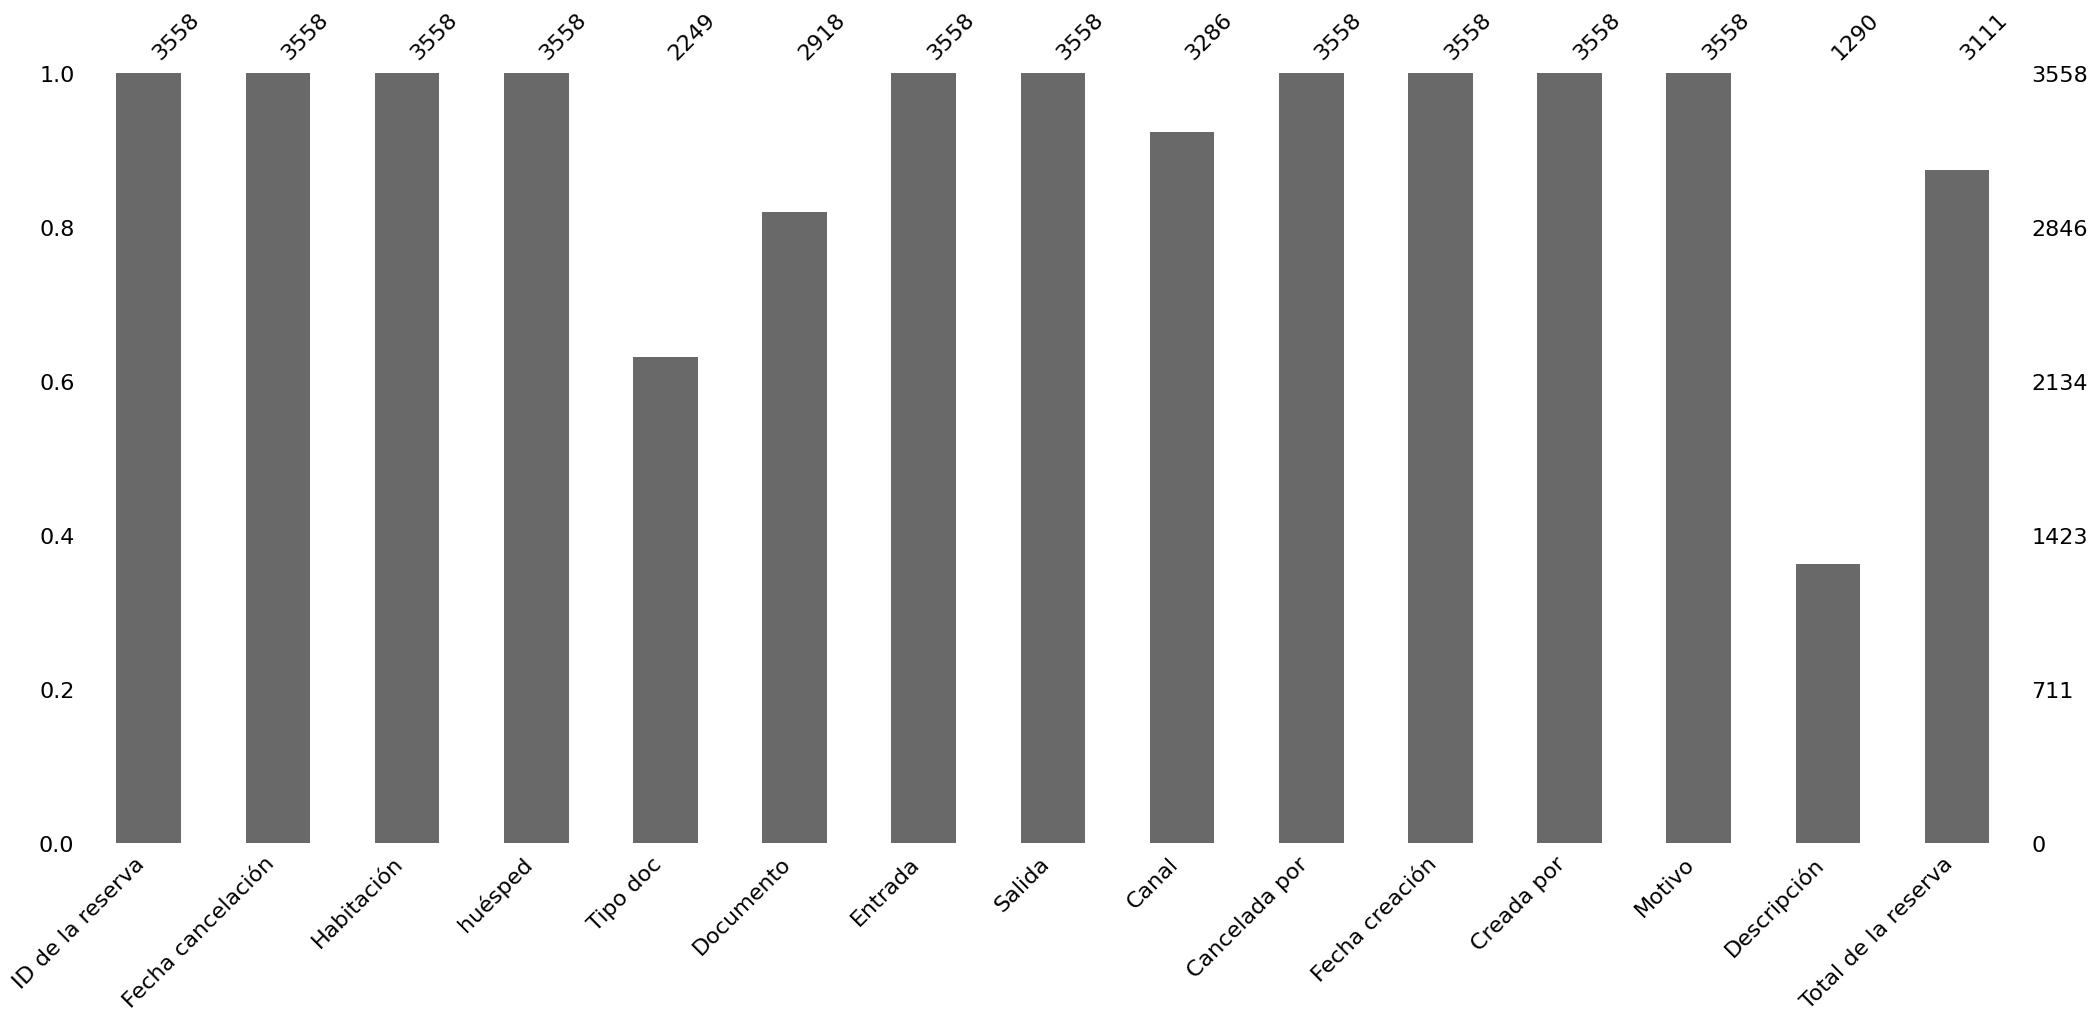

In [59]:
msno.bar(df)
plt.show()

Variables con valores nulos:


,Variable,Nulos,% Nulos
13,Descripción,2268,63.74
4,Tipo doc,1309,36.79
5,Documento,640,17.99
14,Total de la reserva,447,12.56
8,Canal,272,7.64


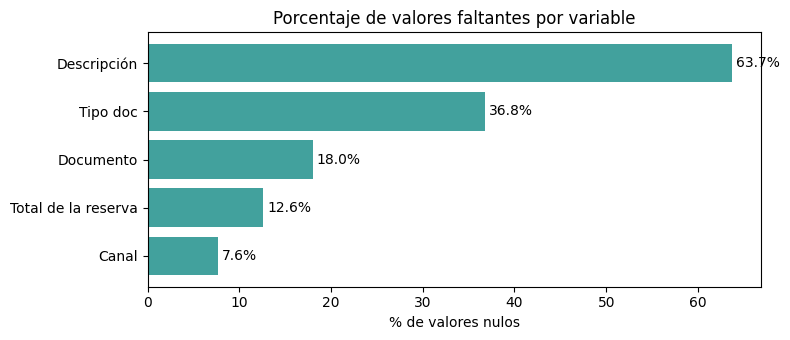

In [60]:
nulos = df.isnull().sum().reset_index()
nulos.columns = ['Variable', 'Nulos']
nulos['% Nulos'] = (nulos['Nulos'] / len(df) * 100).round(2)
nulos = nulos[nulos['Nulos'] > 0].sort_values('% Nulos', ascending=False)

print('Variables con valores nulos:')
display(nulos)

PALETTE = sns.color_palette("viridis", n_colors=len(nulos))
fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(nulos['Variable'], nulos['% Nulos'], color=PALETTE[2], alpha=0.85)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_xlabel('% de valores nulos')
ax.set_title('Porcentaje de valores faltantes por variable')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [61]:
# Variables Categoricas
cat_cols_orig = ['Canal', 'Cancelada por', 'Creada por', 'Motivo', 'Tipo doc', 'Habitación']
for col in cat_cols_orig:
    print(f'\n{col} — {df[col].nunique()} valores únicos')
    print(df[col].value_counts().head(10).to_string())


Canal — 20 valores únicos
Canal
Booking Engine                  854
Booking.com                     565
Venta Directa x Vendedor        367
Venta por agencia               266
Venta Libardo Melo              251
Venta Sandra Ospina             230
WhatsApp Recepción              158
Hotel Portoalegre               146
Venta Puerta                    144
Convenio con persona natural     65

Cancelada por — 13 valores únicos
Cancelada por
Recepción            924
Booking Engine       752
Libardo              525
Sandra Ospina        518
Lobbybookings        392
Comercial            111
Mantenimiento         96
Hotel PortoAlegre     92
Administración        59
Edwar Quintero        42

Creada por — 13 valores únicos
Creada por
Booking Engine       848
Sandra Ospina        592
Lobbybookings        572
Libardo              548
Recepción            519
Mantenimiento        119
Comercial            112
Hotel PortoAlegre     79
Edwar Quintero        63
Administración        47

Motivo — 7 val

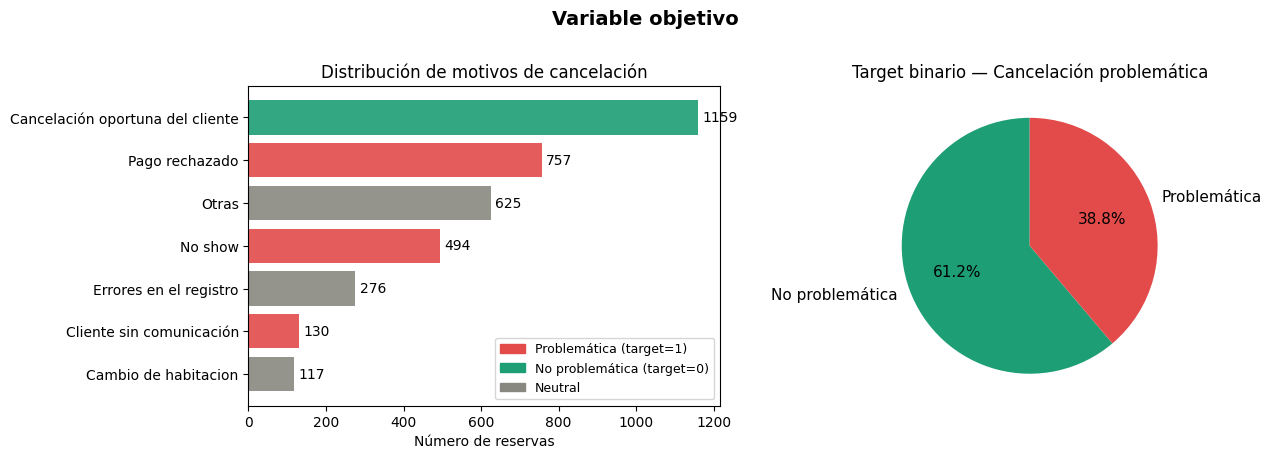


Cancelaciones problemáticas: 1,381 (38.8%)
Cancelaciones no problemáticas: 2,177 (61.2%)


In [62]:
# Distribucion de Variable Objetivo
motivo_cnt = df['Motivo'].value_counts()

colores_motivo = [
    '#1D9E75',  # Cancelación oportuna  → no problemática
    '#E24B4A',  # Pago rechazado        → problemática
    '#888780',  # Otras
    '#E24B4A',  # No show               → problemática
    '#888780',  # Errores en registro
    '#E24B4A',  # Sin comunicación      → problemática
    '#888780',  # Cambio de habitación
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars = axes[0].barh(motivo_cnt.index, motivo_cnt.values, color=colores_motivo, alpha=0.9)
axes[0].bar_label(bars, padding=3, fontsize=10)
axes[0].set_title('Distribución de motivos de cancelación')
axes[0].invert_yaxis()
axes[0].set_xlabel('Número de reservas')

from matplotlib.patches import Patch
leyenda = [Patch(color='#E24B4A', label='Problemática (target=1)'),
           Patch(color='#1D9E75', label='No problemática (target=0)'),
           Patch(color='#888780', label='Neutral')]
axes[0].legend(handles=leyenda, fontsize=9, loc='lower right')

# Target binario
target_temp = df['Motivo'].isin(['No show', 'Pago rechazado', 'Cliente sin comunicación'])
tc = target_temp.value_counts()
axes[1].pie(
    tc.values, labels=['No problemática', 'Problemática'],
    colors=['#1D9E75', '#E24B4A'], autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 11}
)
axes[1].set_title('Target binario — Cancelación problemática')

plt.suptitle('Variable objetivo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\nCancelaciones problemáticas: {target_temp.sum():,} ({target_temp.mean()*100:.1f}%)')
print(f'Cancelaciones no problemáticas: {(~target_temp).sum():,} ({(~target_temp).mean()*100:.1f}%)')

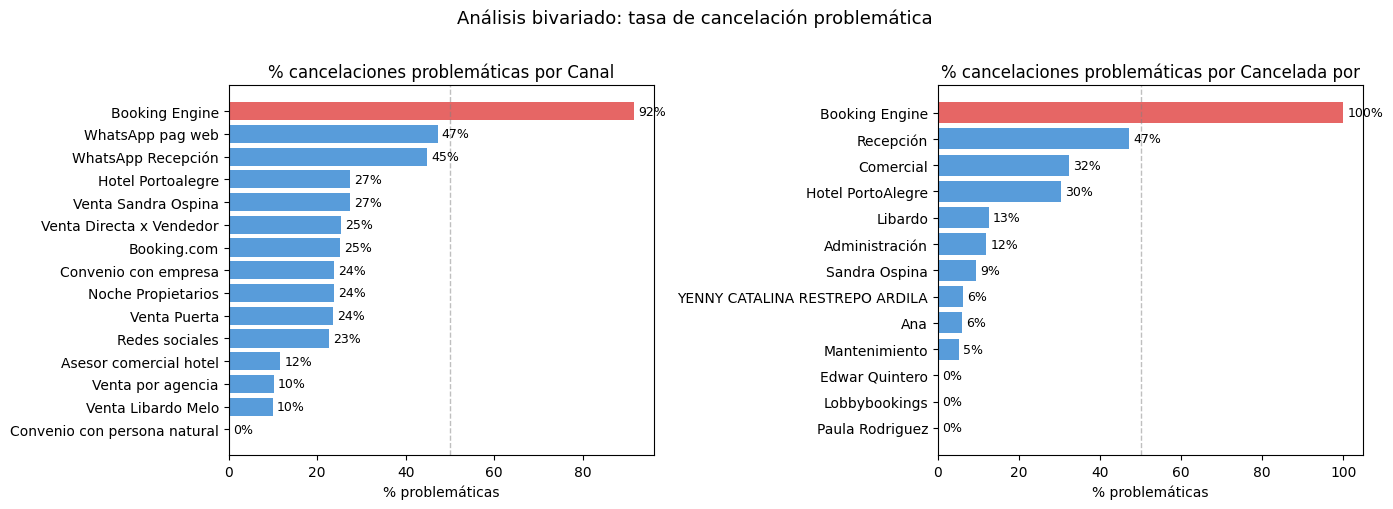

In [63]:
df_temp = df.copy()
df_temp['target'] = df_temp['Motivo'].isin(['No show', 'Pago rechazado', 'Cliente sin comunicación']).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

canal_rate = df_temp.groupby('Canal')['target'].agg(['mean', 'count']).sort_values('mean', ascending=False)
canal_rate = canal_rate[canal_rate['count'] >= 20]  # Al menos 20 reservas
canal_rate['mean_pct'] = canal_rate['mean'] * 100

colors_canal = ['#E24B4A' if v > 50 else '#3B8BD4' for v in canal_rate['mean_pct']]
bars = axes[0].barh(canal_rate.index, canal_rate['mean_pct'], color=colors_canal, alpha=0.85)
axes[0].bar_label(bars, fmt='%.0f%%', padding=3, fontsize=9)
axes[0].set_title('% cancelaciones problemáticas por Canal')
axes[0].invert_yaxis()
axes[0].axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0].set_xlabel('% problemáticas')

canc_rate = df_temp.groupby('Cancelada por')['target'].agg(['mean', 'count']).sort_values('mean', ascending=False)
canc_rate['mean_pct'] = canc_rate['mean'] * 100
colors_canc = ['#E24B4A' if v > 50 else '#3B8BD4' for v in canc_rate['mean_pct']]
bars2 = axes[1].barh(canc_rate.index, canc_rate['mean_pct'], color=colors_canc, alpha=0.85)
axes[1].bar_label(bars2, fmt='%.0f%%', padding=3, fontsize=9)
axes[1].set_title('% cancelaciones problemáticas por Cancelada por')
axes[1].invert_yaxis()
axes[1].axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('% problemáticas')

plt.suptitle('Análisis bivariado: tasa de cancelación problemática', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 3. Preprocesamiento

In [64]:
# Parsear Fechas
df = df.copy()
date_cols = ['Fecha cancelación', 'Entrada', 'Salida', 'Fecha creación']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

print('Fechas parseadas:')
print(df[date_cols].dtypes)
print('\nNulos en fechas:')
print(df[date_cols].isnull().sum())

Fechas parseadas:
Fecha cancelación    datetime64[ns]
Entrada              datetime64[ns]
Salida               datetime64[ns]
Fecha creación       datetime64[ns]
dtype: object

Nulos en fechas:
Fecha cancelación    0
Entrada              0
Salida               0
Fecha creación       0
dtype: int64


In [65]:
# Crear nuevas variables derivadas de la base de datos inicial

df['noches_reserva'] = (df['Salida'] - df['Entrada']).dt.days
df['dias_hasta_entrada'] = (df['Entrada'] - df['Fecha cancelación']).dt.days
df['dias_anticipacion_cancelacion'] = (df['Fecha cancelación'] - df['Fecha creación']).dt.days
df['mes_entrada'] = df['Entrada'].dt.month
df['dia_semana_entrada'] = df['Entrada'].dt.dayofweek      # 0=Lun, 6=Dom
df['es_fin_de_semana'] = df['dia_semana_entrada'].isin([4, 5, 6]).astype(int)
df['mes_creacion'] = df['Fecha creación'].dt.month
df['hora_cancelacion'] = df['Fecha cancelación'].dt.hour

In [66]:
# Limpiar y convertir total de reserva
df['total_cop'] = (
    df['Total de la reserva']
    .str.replace('COP ', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.replace('.', '', regex=False)
    .astype(float) / 100
)

In [67]:
# Variable objetivo binaria
MOTIVOS_PROB = ['No show', 'Pago rechazado', 'Cliente sin comunicación']
df['target'] = df['Motivo'].isin(MOTIVOS_PROB).astype(int)

print('Variables nuevas creadas:')
nuevas = ['noches_reserva','dias_hasta_entrada','dias_anticipacion_cancelacion',
          'mes_entrada','dia_semana_entrada','es_fin_de_semana','mes_creacion',
          'hora_cancelacion','total_cop','target']
display(df[nuevas].describe().round(2))

Variables nuevas creadas:


,noches_reserva,dias_hasta_entrada,dias_anticipacion_cancelacion,mes_entrada,dia_semana_entrada,es_fin_de_semana,mes_creacion,hora_cancelacion,total_cop,target
count,3558.00,3558.00,3558.00,3558.00,3558.00,3558.00,3558.00,3558.00,3111.00,3558.00
mean,2.49,22.87,26.55,6.16,3.49,0.58,6.34,13.35,868253.46,0.39
std,1.46,63.64,55.51,3.89,1.84,0.49,3.80,4.85,827778.83,0.49
min,0.00,-348.00,0.00,1.00,0.00,0.00,1.00,0.00,30000.00,0.00
25%,1.00,-1.00,0.00,3.00,2.00,0.00,3.00,10.00,367479.00,0.00
50%,2.00,7.00,2.00,6.00,4.00,1.00,6.00,13.00,701782.00,0.00
75%,3.00,29.00,28.00,10.00,5.00,1.00,10.00,17.00,1114027.50,1.00
max,28.00,441.00,479.00,12.00,6.00,1.00,12.00,23.00,18729587.00,1.00


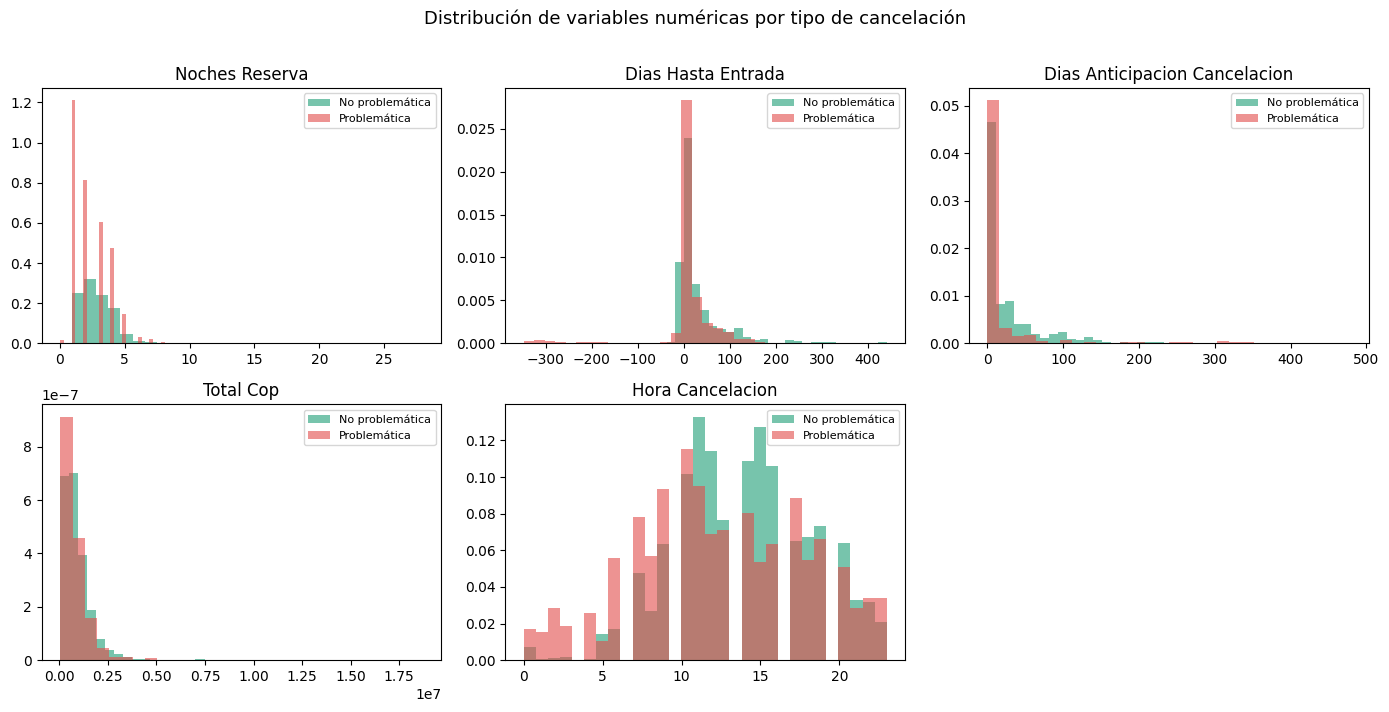

In [68]:
#  Distribuciones de variables numéricas derivadas ──────────────────────
num_feats = ['noches_reserva', 'dias_hasta_entrada',
             'dias_anticipacion_cancelacion', 'total_cop', 'hora_cancelacion']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(num_feats):
    data0 = df[df['target'] == 0][col].dropna()
    data1 = df[df['target'] == 1][col].dropna()
    axes[i].hist(data0, bins=30, alpha=0.6, color='#1D9E75', label='No problemática', density=True)
    axes[i].hist(data1, bins=30, alpha=0.6, color='#E24B4A', label='Problemática', density=True)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Distribución de variables numéricas por tipo de cancelación', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

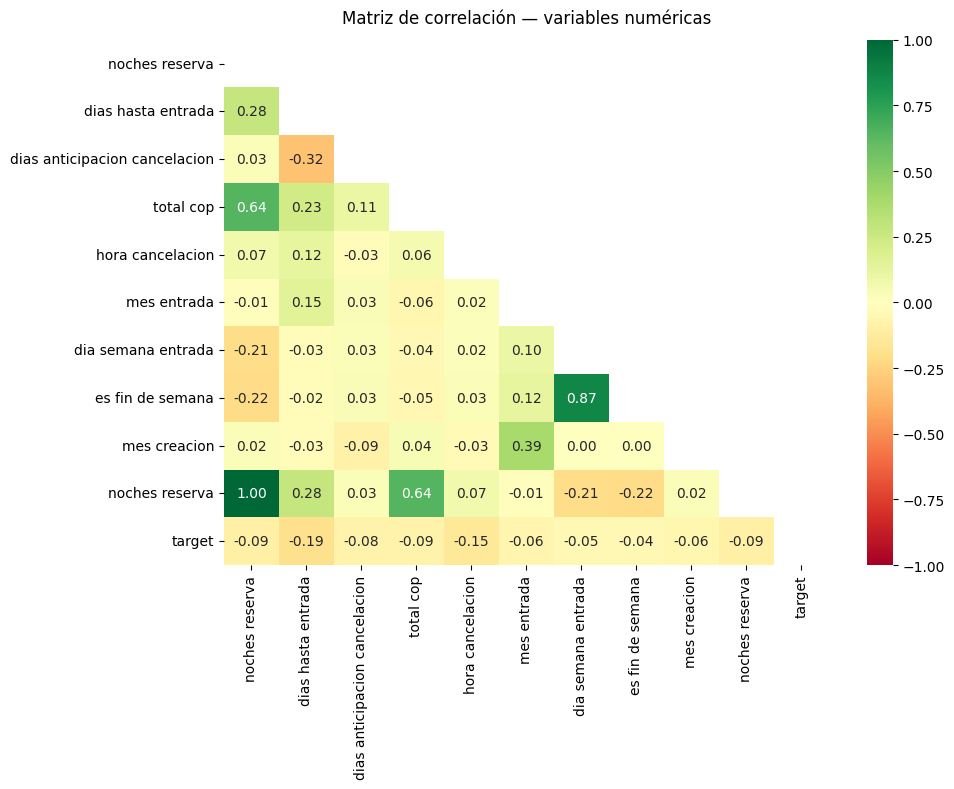

In [69]:
# Correlación entre variables numéricas ────────────────────────────────
num_all = num_feats + ['mes_entrada', 'dia_semana_entrada', 'es_fin_de_semana',
                        'mes_creacion', 'noches_reserva', 'target']
corr = df[num_all].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=[c.replace('_',' ') for c in corr.columns],
            yticklabels=[c.replace('_',' ') for c in corr.index])
ax.set_title('Matriz de correlación — variables numéricas', pad=12)
plt.tight_layout()
plt.show()

## 4. Imputacion de datos faltantes

In [70]:
# Selección de variables para el modelo
FEATURES_NUM = [
    'noches_reserva', 'dias_hasta_entrada', 'dias_anticipacion_cancelacion',
    'mes_entrada', 'dia_semana_entrada', 'es_fin_de_semana',
    'mes_creacion', 'hora_cancelacion', 'total_cop'
]
FEATURES_CAT = ['Canal', 'Cancelada por', 'Creada por', 'Tipo doc', 'Habitación']
TARGET = 'target'

df_model = df[FEATURES_NUM + FEATURES_CAT + [TARGET]].copy()

print('Nulos antes de imputación:')
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Nulos antes de imputación:
total_cop     447
Canal         272
Tipo doc     1309
dtype: int64


In [71]:
# Imputación categórica: rellenar con 'Desconocido' ────────────────────
for col in ['Canal', 'Tipo doc', 'Habitación']:
    df_model[col].fillna('Desconocido', inplace=True)

print('✅ Imputación categórica completada')
print(df_model[FEATURES_CAT].isnull().sum())

✅ Imputación categórica completada
Canal            0
Cancelada por    0
Creada por       0
Tipo doc         0
Habitación       0
dtype: int64


/tmp/ipykernel_146/986543452.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].fillna('Desconocido', inplace=True)


In [72]:
from sklearn.preprocessing import LabelEncoder

# ── Codificación de variables categóricas (Label Encoding) ────────────────
encoders = {}
for col in FEATURES_CAT:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    print(f'  {col}: {len(le.classes_)} categorías codificadas')

print('\n✅ Codificación completada')

  Canal: 21 categorías codificadas
  Cancelada por: 13 categorías codificadas
  Creada por: 13 categorías codificadas
  Tipo doc: 7 categorías codificadas
  Habitación: 49 categorías codificadas

✅ Codificación completada


In [73]:
from sklearn.impute import SimpleImputer

# ── Imputación numérica con mediana (via SimpleImputer) ───────────────────
X = df_model.drop(TARGET, axis=1).astype(float)
y = df_model[TARGET]

print('Nulos en variables numéricas antes de imputación:')
print(X[FEATURES_NUM].isnull().sum()[X[FEATURES_NUM].isnull().sum() > 0])

imputer = SimpleImputer(strategy='median')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f'\n✅ Imputación numérica con mediana completada')
print(f'Nulos restantes: {X_imp.isnull().sum().sum()}')

# Resumen de medianas usadas para imputar
medians_used = pd.Series(imputer.statistics_, index=X.columns)
print('\nMedianas usadas para imputación:')
print(medians_used[FEATURES_NUM].round(2))

Nulos en variables numéricas antes de imputación:
total_cop    447
dtype: int64

✅ Imputación numérica con mediana completada
Nulos restantes: 0

Medianas usadas para imputación:
noches_reserva                        2.0
dias_hasta_entrada                    7.0
dias_anticipacion_cancelacion         2.0
mes_entrada                           6.0
dia_semana_entrada                    4.0
es_fin_de_semana                      1.0
mes_creacion                          6.0
hora_cancelacion                     13.0
total_cop                        701782.0
dtype: float64


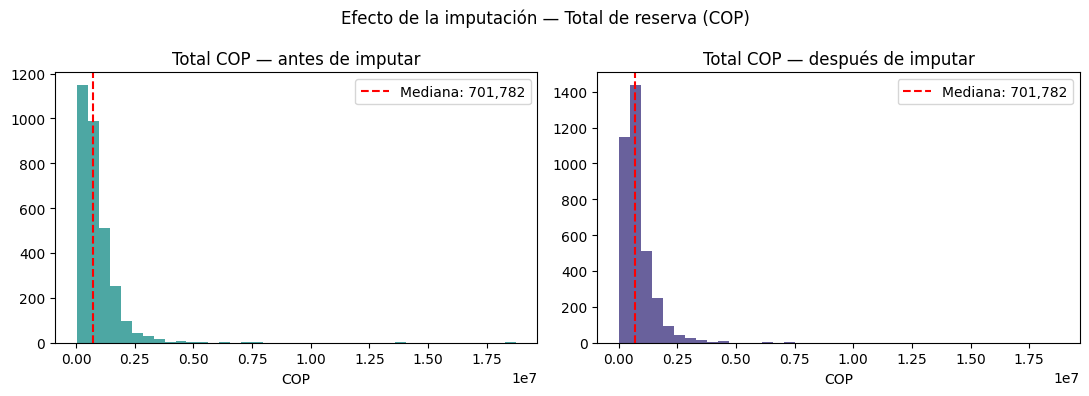

In [74]:
# ── Visualización: impacto de la imputación en total_cop ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df['total_cop'].dropna(), bins=40, color=PALETTE[2], alpha=0.8)
axes[0].set_title('Total COP — antes de imputar')
axes[0].set_xlabel('COP')
axes[0].axvline(df['total_cop'].median(), color='red', linestyle='--', label=f'Mediana: {df["total_cop"].median():,.0f}')
axes[0].legend()

axes[1].hist(X_imp['total_cop'], bins=40, color=PALETTE[0], alpha=0.8)
axes[1].set_title('Total COP — después de imputar')
axes[1].set_xlabel('COP')
axes[1].axvline(X_imp['total_cop'].median(), color='red', linestyle='--', label=f'Mediana: {X_imp["total_cop"].median():,.0f}')
axes[1].legend()

plt.suptitle('Efecto de la imputación — Total de reserva (COP)', fontsize=12)
plt.tight_layout()
plt.show()